In [ ]:
!pip install jax flax grain tiktoken matplotlib

JAX  → math engine

Flax → neural network framework

JAX is a library for doing math with arrays, similar to NumPy. In fact, you write code almost the same way you do with NumPy. 
- The difference is that JAX can automatically compute gradients (for machine learning) and can run the same code much faster on GPUs or TPUs.
- NumPy is great for regular numerical computing on CPU, while JAX is like a more powerful NumPy that can also do automatic differentiation and hardware acceleration, which makes it very useful for machine learning.

Flax is a library built on top of JAX that helps you build and train neural networks easily. 
- If JAX is like NumPy with extra powers (speed, gradients, GPUs), then Flax is the tool that organizes those powers so you can build deep learning models like CNNs, transformers without writing everything from scratch.

In [1]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import grain.python as pygrain
import tiktoken
import optax
import matplotlib.pyplot as plt

In [2]:

num_transformer_blocks = 6
maxlen = 128
embed_dim = 192
num_heads = 6
feed_forward_dim = int(2/3 * 4 * embed_dim)
batch_size = 24
num_epochs = 3


In [3]:
jnp.ones((5, 5))

Array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]], dtype=float32)

In [4]:
jnp.tril(jnp.ones((5, 5)))

Array([[1., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0.],
       [1., 1., 1., 0., 0.],
       [1., 1., 1., 1., 0.],
       [1., 1., 1., 1., 1.]], dtype=float32)

In [ ]:
# This function creates a mask that ensures: Each token can only attend to itself and previous tokens, never future tokens.
def causal_attention_mask(seq_len):
    return jnp.tril(jnp.ones((seq_len, seq_len)))

In [6]:
# tiktoken is a fast tokenizer library created by OpenAI.
tokenizer = tiktoken.get_encoding("gpt2")

In [7]:
tokenizer.encode("Hello world")

[15496, 995]

In [8]:
tokenizer.max_token_value

50256

In [9]:
vocab_size = tokenizer.n_vocab
vocab_size

50257

````markdown
### How Token IDs Become Embeddings

`tiktoken` only gives **token IDs**.

The **embeddings come from your model's embedding layer**.

Example embedding layer:

`self.token_emb = nnx.Embed(vocab_size, embed_dim)`

This creates an **embedding matrix**.

**Shape**

`(vocab_size, embed_dim)`

Example:

`50257 × 768`

### Example

Suppose your tokenizer outputs:

`[10]`

The embedding layer performs a **row lookup**.

Mathematically:

`embedding = embedding_matrix[10]`

So the model simply retrieves **row 10** from the embedding matrix, which becomes the embedding vector for that token.



In [70]:
# rngs = random number generators. We will use them to initialize the parameters of our model.
# nnx.Embed = A lookup table that converts token IDs into vectors.
class TokenAndPositionEmbedding(nnx.Module):
    def __init__(self, maxlen, vocab_size, embed_dim, *, rngs):
        self.token_emb = nnx.Embed(vocab_size, embed_dim, rngs=rngs) # Create embedding table for tokens
        self.pos_emb = nnx.Embed(maxlen, embed_dim, rngs=rngs) # Create embedding table for positions

    def __call__(self, x):
        seq_len = x.shape[1]
        positions = jnp.arange(seq_len)[None, :]
        return self.token_emb(x) + self.pos_emb(positions) # Add token and position embeddings together



### Transformer Architecture

```
Transformer
   │
   ├── Layer 1
   │      ├── Multi-Head Attention
   │      │      ├── Head 1 (Q,K,V)
   │      │      ├── Head 2 (Q,K,V)
   │      │      └── Head 3 (Q,K,V)
   │      └── Feed Forward
   │
   ├── Layer 2
   │      ├── Multi-Head Attention
   │      └── Feed Forward
   │
   └── Layer 3
          ├── Multi-Head Attention
          └── Feed Forward
```


### One Layer with Multiple Heads

```
Input Embedding
       │
       ▼
  Multi-Head Attention
       │
       ├── Head 1 (Q,K,V)
       ├── Head 2 (Q,K,V)
       ├── Head 3 (Q,K,V)
       ├── Head 4 (Q,K,V)
       ├── Head 5 (Q,K,V)
       ├── Head 6 (Q,K,V)
       ├── Head 7 (Q,K,V)
       └── Head 8 (Q,K,V)
```

### How multi head works in a transformer

```
Input Token Embeddings
        │
        ▼
      Multi-Head Attention
        │
        ├── Head 1 → focuses on grammar
        ├── Head 2 → focuses on long-distance links
        ├── Head 3 → focuses on pronouns
        ├── Head 4 → focuses on structure
        └── Head 5 → focuses on modifiers

```

In [71]:


class TransformerBlock(nnx.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, *, rngs):
        self.attention = nnx.MultiHeadAttention(
            num_heads=num_heads, # Number of attention heads (e.g., 8 or 12)
            in_features=embed_dim, # Size of input features for each token embedding
            qkv_features=embed_dim, # Dimension used to compute Query, Key, and Value projections
            out_features=embed_dim,  # Output dimension after attention (usually same as embedding size)
            decode=False, # decode=False means this is used for training or full-sequence processing. If True, it would be used for autoregressive decoding (generation)
            rngs=rngs # Random number generators used to initialize attention weights
        )
        
    def __call__(self, x, mask=None):
        # x → input tensor containing token embeddings. shape of x: (batch_size, seq_len, embed_dim)
        # mask → optional attention mask (e.g., causal mask to block future tokens so that, model predicts next token based on previous tokens only). 
        attn_out = self.attention(x, mask=mask) # Apply multi-head self-attention to input x
        x = x + attn_out # Add the original input x to the attention output
        return x # Return the updated token representations after attention


 __init__ runs when the object is created

__call__ runs when you use the object like a function


`block = TransformerBlock(embed_dim=512, num_heads=8, ff_dim=2048, rngs=rngs)`



```
Object created
     ↓
__init__ runs

```


```
output = `block(x)` ===> block.__call__(x)

Object created → __init__
Object used as function → __call__
```

In [72]:
class MiniGPT(nnx.Module): 

    def __init__(self, maxlen=maxlen, vocab_size=vocab_size, embed_dim=embed_dim, num_heads=num_heads,
                 feed_forward_dim=feed_forward_dim, num_transformer_blocks=num_transformer_blocks, *, rngs=nnx.Rngs(0)): 

        self.maxlen = maxlen # Store the maximum sequence length the model can process

        self.embedding = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim, rngs=rngs) # Create a layer that converts token IDs into token embeddings and adds positional embeddings

        self.transformer_blocks = nnx.List([
            TransformerBlock(embed_dim, num_heads, feed_forward_dim, rngs=rngs)
            for _ in range(num_transformer_blocks)
        ]) # Create a list of multiple TransformerBlock layers.

        self.output_layer = nnx.Linear(embed_dim, vocab_size, use_bias=False, rngs=rngs) # Final linear layer that converts transformer outputs into vocabulary-sized logits for prediction
        

    def causal_attention_mask(self, seq_len): # Define a function to generate a causal mask that prevents tokens from attending to future tokens
        return jnp.tril(jnp.ones((seq_len, seq_len)))  


    def __call__(self, token_ids): # Forward pass of the MiniGPT model that takes token IDs as input

        seq_len = token_ids.shape[1] # Extract the sequence length of the input tokens

        mask = self.causal_attention_mask(seq_len) # Generate a causal attention mask for the current sequence length

        x = self.embedding(token_ids) # Convert token IDs into embeddings with positional information

        for block in self.transformer_blocks: # Iterate through each transformer block in the model
            x = block(x, mask=mask) # Pass the embeddings through the transformer block with the attention mask applied 

        logits = self.output_layer(x) # Project the transformer outputs to vocabulary logits for each token position

        return logits # Return the predicted logits used to compute next-token probabilities

In [73]:
model = MiniGPT()

In [74]:
model

MiniGPT( # Param: 20,212,608 (80.9 MB)
  maxlen=128,
  embedding=TokenAndPositionEmbedding( # Param: 9,673,920 (38.7 MB)
    token_emb=Embed( # Param: 9,649,344 (38.6 MB)
      embedding=Param( # 9,649,344 (38.6 MB)
        value=Array(shape=(50257, 192), dtype=dtype('float32'))
      ),
      num_embeddings=50257,
      features=192,
      dtype=dtype('float32'),
      param_dtype=float32,
      promote_dtype=<function promote_dtype at 0x10d09cd60>
    ),
    pos_emb=Embed( # Param: 24,576 (98.3 KB)
      embedding=Param( # 24,576 (98.3 KB)
        value=Array(shape=(128, 192), dtype=dtype('float32'))
      ),
      num_embeddings=128,
      features=192,
      dtype=dtype('float32'),
      param_dtype=float32,
      promote_dtype=<function promote_dtype at 0x10d09cd60>
    )
  ),
  transformer_blocks=List([
    TransformerBlock( # Param: 148,224 (592.9 KB)
      attention=MultiHeadAttention( # Param: 148,224 (592.9 KB)
        num_heads=6,
        in_features=192,
        qkv_feature

In [75]:
from pathlib import Path

def load_capital_facts_from_file(
    file_path,
    max_facts=None
):
    """
    Efficiently load capital facts from a text file.
    Each fact ends with <|endoftext|>.
    """

    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(f"Data file not found: {file_path}")

    print(f"Loading capital facts from {file_path}...")

    capital_facts = []
    current_fact = []

    with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:

            if '<|endoftext|>' in line:

                parts = line.split('<|endoftext|>')

                for part in parts[:-1]:
                    current_fact.append(part)

                    fact_text = ''.join(current_fact).strip()

                    if fact_text:
                        capital_facts.append(fact_text + '<|endoftext|>')

                        if max_facts and len(capital_facts) >= max_facts:
                            break

                    current_fact = []

                if parts[-1].strip():
                    current_fact = [parts[-1]]
                else:
                    current_fact = []

                if max_facts and len(capital_facts) >= max_facts:
                    break

            else:
                current_fact.append(line)

        if current_fact and (not max_facts or len(capital_facts) < max_facts):

            fact_text = ''.join(current_fact).strip()

            if fact_text:
                capital_facts.append(fact_text + '<|endoftext|>')

    print(f"Loaded {len(capital_facts):,} capital facts")

    return capital_facts

In [76]:
facts = load_capital_facts_from_file(
    file_path="capitals.txt",
    max_facts=100
)

Loading capital facts from capitals.txt...
Loaded 100 capital facts


In [77]:
facts

['The capital of Afghanistan is Kabul.<|endoftext|>',
 'The capital of Albania is Tirana.<|endoftext|>',
 'The capital of Algeria is Algiers.<|endoftext|>',
 'The capital of Argentina is Buenos Aires.<|endoftext|>',
 'The capital of Australia is Canberra.<|endoftext|>',
 'The capital of Austria is Vienna.<|endoftext|>',
 'The capital of Bangladesh is Dhaka.<|endoftext|>',
 'The capital of Belgium is Brussels.<|endoftext|>',
 'The capital of Brazil is Brasilia.<|endoftext|>',
 'The capital of Canada is Ottawa.<|endoftext|>',
 'The capital of China is Beijing.<|endoftext|>',
 'The capital of Denmark is Copenhagen.<|endoftext|>',
 'The capital of Egypt is Cairo.<|endoftext|>',
 'The capital of Finland is Helsinki.<|endoftext|>',
 'The capital of France is Paris.<|endoftext|>',
 'The capital of Germany is Berlin.<|endoftext|>',
 'The capital of Greece is Athens.<|endoftext|>',
 'The capital of India is New Delhi.<|endoftext|>',
 'The capital of Indonesia is Jakarta.<|endoftext|>',
 'The ca

In [18]:
class CapitalFactsDataset:
    def __init__(self, capital_facts, maxlen, tokenizer):
        self.capital_facts = capital_facts
        self.maxlen = maxlen
        self.tokenizer = tokenizer
        self.end_token = tokenizer.encode(
            "<|endoftext|>", allowed_special={"<|endoftext|>"}
        )[0]

    def __len__(self):
        return len(self.capital_facts)

    def __getitem__(self, idx):
        fact = self.capital_facts[idx]

        tokens = self.tokenizer.encode(
            fact, allowed_special={"<|endoftext|>"}
        )

        if len(tokens) > self.maxlen:
            tokens = tokens[:self.maxlen]

        tokens.extend([0] * (self.maxlen - len(tokens))) #This line pads the token list with zeros so that every sequence becomes exactly maxlen tokens long.
        # [1542, 318, 262, 3139, 286, 4881, 0, 0, 0, 0]

        return tokens

In [19]:
def load_and_preprocess_capital_data(
    file_path,
    batch_size,
    maxlen,
    max_facts=100_000,
    num_epochs=1,
    shuffle=False,
    seed=42
):
    """
    Load and preprocess capital facts dataset.

    Args:
        file_path: Path to dataset file
        batch_size: Training batch size
        maxlen: Maximum sequence length
        max_facts: Maximum number of facts to load
        num_epochs: Number of training epochs
        shuffle: Shuffle dataset
        seed: Random seed

    Returns:
        (DataLoader, estimated_batches_per_epoch)
    """

    print(f"Loading data from {file_path} (max {max_facts} facts)")

    # Load facts
    capital_facts = load_capital_facts_from_file(
        file_path,
        max_facts=max_facts
    )

    if len(capital_facts) == 0:
        raise ValueError("No valid capital facts found in the dataset")

    # Estimate batches
    # estimated_batches_per_epoch tells us how many batches are needed to process the whole dataset once (one epoch)
    estimated_batches_per_epoch = len(capital_facts) // batch_size

    print(f"Estimated batches per epoch: {estimated_batches_per_epoch:,}")

    # Create dataset
    dataset = CapitalFactsDataset(capital_facts, maxlen, tokenizer)

    # Sampler
    # A sampler decides which data sample from the dataset should be read next.
    # It can shuffle the data, so the model doesn’t always see examples in the same order.
    # This helps training because the model learns from a more mixed and unbiased sequence of data.
    # kind of a sampling strategy that determines the order in which data samples are fed into the model during training.
    sampler = pygrain.IndexSampler(
        num_records=len(dataset),
        shuffle=shuffle,
        seed=seed,
        shard_options=pygrain.NoSharding(),
        num_epochs=num_epochs,
    )

    # DataLoader
    # The DataLoader reads samples from the dataset using the sampler and groups them into batches for training. 
    # It makes sure the model receives data in batch form instead of one sample at a time.
    dataloader = pygrain.DataLoader(
        data_source=dataset,
        sampler=sampler,
        operations=[
            pygrain.Batch(batch_size=batch_size, drop_remainder=True)
        ]
    )

    print(f"Created DataLoader with batch_size={batch_size}, maxlen={maxlen}")

    return dataloader, estimated_batches_per_epoch

Do we seriously need Data Loader?

- LLMs train on batches, not single samples.
- Training works better when data is mixed.
- DataLoader automatically: loads samples, groups batches, moves through epochs


We use a DataLoader to efficiently load, shuffle, and batch data before feeding it to the model.
It helps training run faster and more organized, especially for large datasets.

In [20]:
text_dl, batches_per_epoch = load_and_preprocess_capital_data(
    file_path="capitals.txt",
    batch_size=32,
    maxlen=24,
    max_facts=None,
    shuffle=True,
    seed=42
)

Loading data from capitals.txt (max None facts)
Loading capital facts from capitals.txt...
Loaded 795 capital facts
Estimated batches per epoch: 24
Created DataLoader with batch_size=32, maxlen=24


In [21]:
text_dl

In [22]:
batches_per_epoch

24

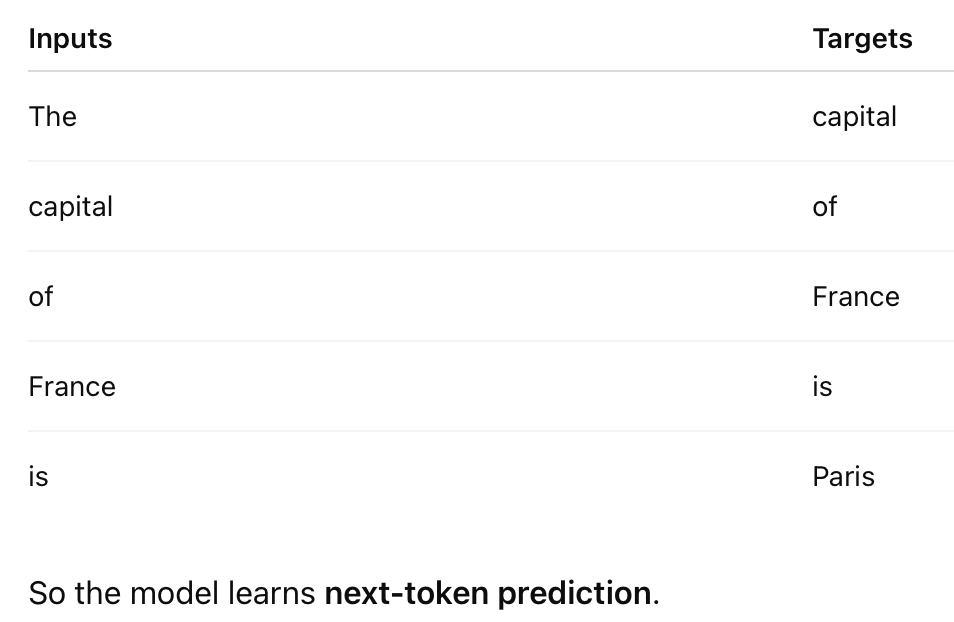

Cross entropy measures how wrong the model's predicted probabilities are compared to the correct answer.

If the model gives high probability to the correct answer → low loss

If the model gives low probability to the correct answer → high loss

In [24]:
num_epochs=3 # One Epoch : One complete pass through the entire dataset.
total_steps = batches_per_epoch * num_epochs
warmup_steps = max(1, total_steps // 10)  # 10% warmup
print(f"Total training steps: {total_steps:,}")
print(f"Warmup steps: {warmup_steps:,}")

Total training steps: 72
Warmup steps: 7



At the start of training, model weights are random.

If the learning rate is high immediately:
- gradients can explode
- training becomes unstable

So we start with a small learning rate and slowly increase it during warmup.

In [26]:
# This code creates a learning rate schedule that first increases the learning rate during warmup 
# and then gradually decreases it using cosine decay during training.
# Why we do this in LLM training
    # • warmup prevents gradient instability
    # • high LR early helps fast learning
    # • gradual decay helps fine-tuning later
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0, #learning rate at step 0
    peak_value=3e-4, #maximum learning rate reached after warmup
    warmup_steps=warmup_steps, #steps used to increase LR from init_value to peak_value
    decay_steps=total_steps, #steps used to decrease LR from peak_value to end_value
    end_value=1e-5 #minimum learning rate at the end of the schedule
)

In [28]:
# The optimizer changes the model weights step-by-step to reduce the training loss.
# AdamW is very common for training transformers and LLMs.
optimizer = nnx.Optimizer(
    model,
    optax.adamw(
        learning_rate=lr_schedule,
        weight_decay=0.01
    ),
    wrt=nnx.Param
)

In [29]:
# This code creates a metric tracker to monitor the training loss during training.
# It keeps track of the average loss value across training steps.
# During training, the loss changes every batch. This metric helps compute the running average loss.
metrics = nnx.MultiMetric(
    loss=nnx.metrics.Average('loss'),
)

@nnx.jit compiles the function using JAX so it runs as optimized machine code instead of normal Python execution.

This makes repeated operations like training steps much faster, especially on GPUs.

In [78]:
# This function performs one training step: 
# it computes the loss, calculates gradients, updates metrics, and updates the model weights using the optimizer.
@nnx.jit
def train_step(model, optimizer, metrics, batch):

    #This function calculates the loss value for a batch of training data.
    def loss_fn(model, batch): 
        inputs, targets = batch #inputs: tokens fed into the model, targets: the expected next tokens that the model should predict
        logits = model(inputs) # The model processes the input tokens and produces logits. Logits are raw prediction scores before softmax.
        loss = optax.softmax_cross_entropy_with_integer_labels(
            logits, targets
        ).mean()
        return loss, logits
    # This creates a function that will compute:
    #     loss_value → training loss
    #     auxiliary_data → logits (because has_aux=True)
    #     gradients → derivatives of loss w.r.t model parameters
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
    # (loss, logits), grads = grad_fn(model)
    (loss, logits), grads = grad_fn(model, batch)

    # update metrics
    metrics.update(loss=loss, logits=logits, labels=batch[1])

    # update model paramters using the computed gradients
    optimizer.update(model, grads)

In [79]:
num_epochs=20

In [80]:
metrics_history = {'train_loss': []}

for epoch in range(num_epochs):
    step = 0

    for batch in text_dl: # Iterate through batches produced by the DataLoader
        input_batch = jnp.array(batch).T.astype(jnp.int32)
        # Convert batch to a JAX array, transpose it to match model input shape, and ensure int32 datatype

        target_batch = jnp.roll(input_batch, -1, axis=1)
        # Shift tokens left by 1 position to create next-token prediction targets

        target_batch = target_batch.at[:, -1].set(0)
        # Set the last token target to 0 since there is no next token after the last position

        print(".", end="")

        train_step(model, optimizer, metrics, (input_batch, target_batch))

        if (step + 1) % 2 == 0:
            for metric, value in metrics.compute().items():
                metrics_history[f'train_{metric}'].append(value)

            metrics.reset()

            current_lr = lr_schedule(step)

            print(
                f"\nEpoch: {epoch+1}, Step {step+1}, "
                f"Loss: {metrics_history['train_loss'][-1]:.4f}, "
                f"LR: {current_lr:.2e}"
            )

        step += 1

..
Epoch: 1, Step 2, Loss: 10.7099, LR: 4.29e-05
..
Epoch: 1, Step 4, Loss: 10.5924, LR: 1.29e-04
..
Epoch: 1, Step 6, Loss: 10.3994, LR: 2.14e-04
..
Epoch: 1, Step 8, Loss: 10.1598, LR: 3.00e-04
..
Epoch: 1, Step 10, Loss: 9.8814, LR: 2.99e-04
..
Epoch: 1, Step 12, Loss: 9.5801, LR: 2.97e-04
..
Epoch: 1, Step 14, Loss: 9.2934, LR: 2.94e-04
..
Epoch: 1, Step 16, Loss: 8.9178, LR: 2.89e-04
..
Epoch: 1, Step 18, Loss: 8.4906, LR: 2.83e-04
..
Epoch: 1, Step 20, Loss: 8.2106, LR: 2.76e-04
..
Epoch: 1, Step 22, Loss: 7.7314, LR: 2.68e-04
..
Epoch: 1, Step 24, Loss: 7.3665, LR: 2.59e-04
..
Epoch: 2, Step 2, Loss: 6.8173, LR: 4.29e-05
..
Epoch: 2, Step 4, Loss: 6.5241, LR: 1.29e-04
..
Epoch: 2, Step 6, Loss: 6.0534, LR: 2.14e-04
..
Epoch: 2, Step 8, Loss: 5.5764, LR: 3.00e-04
..
Epoch: 2, Step 10, Loss: 5.4401, LR: 2.99e-04
..
Epoch: 2, Step 12, Loss: 5.5495, LR: 2.97e-04
..
Epoch: 2, Step 14, Loss: 5.7095, LR: 2.94e-04
..
Epoch: 2, Step 16, Loss: 5.5182, LR: 2.89e-04
..
Epoch: 2, Step 18, Lo

In [81]:
import jax.numpy as jnp

def demo_batch_processing():
    # Example batch coming from DataLoader (batch_size=3, seq_len=4)
    batch = [
        [10, 11, 12, 13],
        [20, 21, 22, 23],
        [30, 31, 32, 33]
    ]

    print("Original batch (from dataloader):")
    print(batch)
    print()

    # Step 1: convert to JAX array
    arr = jnp.array(batch)
    print("Step 1: jnp.array(batch)")
    print(arr)
    print(arr.shape)
    print()

    # Step 2: transpose
    # We transpose so the tensor shape becomes (sequence_length, batch_size), which is the format the model expects for processing tokens across the batch.
    input_batch = arr.T.astype(jnp.int32)
    print("Step 2: transpose (.T) and convert to int32")
    print(input_batch)
    print(input_batch.shape)
    print()

    # Step 3: create targets by shifting tokens
    # We roll the tokens to create next-token prediction targets, and we set the last token to 0 because the final token has no next token.
    target_batch = jnp.roll(input_batch, -1, axis=1)
    print("Step 3: jnp.roll(input_batch, -1, axis=1)")
    print(target_batch)
    print()

    # Step 4: fix last token
    target_batch = target_batch.at[:, -1].set(0)
    print("Step 4: set last column to 0")
    print(target_batch)
    print()

demo_batch_processing()

Original batch (from dataloader):
[[10, 11, 12, 13], [20, 21, 22, 23], [30, 31, 32, 33]]

Step 1: jnp.array(batch)
[[10 11 12 13]
 [20 21 22 23]
 [30 31 32 33]]
(3, 4)

Step 2: transpose (.T) and convert to int32
[[10 20 30]
 [11 21 31]
 [12 22 32]
 [13 23 33]]
(4, 3)

Step 3: jnp.roll(input_batch, -1, axis=1)
[[20 30 10]
 [21 31 11]
 [22 32 12]
 [23 33 13]]

Step 4: set last column to 0
[[20 30  0]
 [21 31  0]
 [22 32  0]
 [23 33  0]]



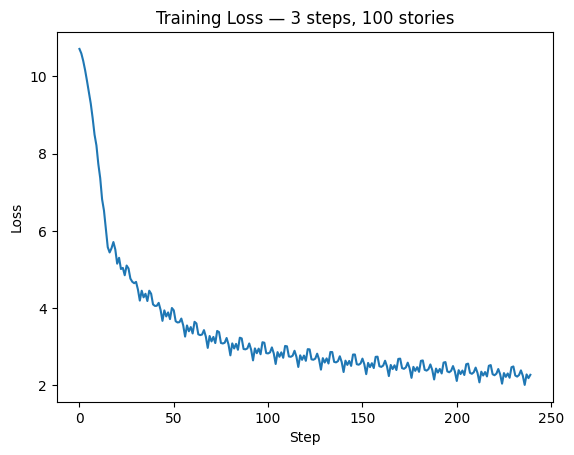

In [82]:
import matplotlib.pyplot as plt
plt.plot(metrics_history['train_loss'])
plt.title('Training Loss — 3 steps, 100 stories')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [83]:
from pathlib import Path
import orbax
# The Orbax module is used to save and load model checkpoints during training.

checkpoint_path = Path.cwd() / "llm_checkpoint.orbax"

checkpointer = orbax.checkpoint.PyTreeCheckpointer()

checkpointer.save(checkpoint_path, nnx.state(model), force=True)
print(f"Model saved as {checkpoint_path}")

Model saved as /Users/praveenreddy/YouTube/JAZ/jaz_0.1/llm_checkpoint.orbax


In [84]:
import orbax
from orbax import checkpoint

from jax.sharding import SingleDeviceSharding 

In [85]:
cpu_device = jax.devices('cpu')[0]
cpu_sharding = SingleDeviceSharding(cpu_device)

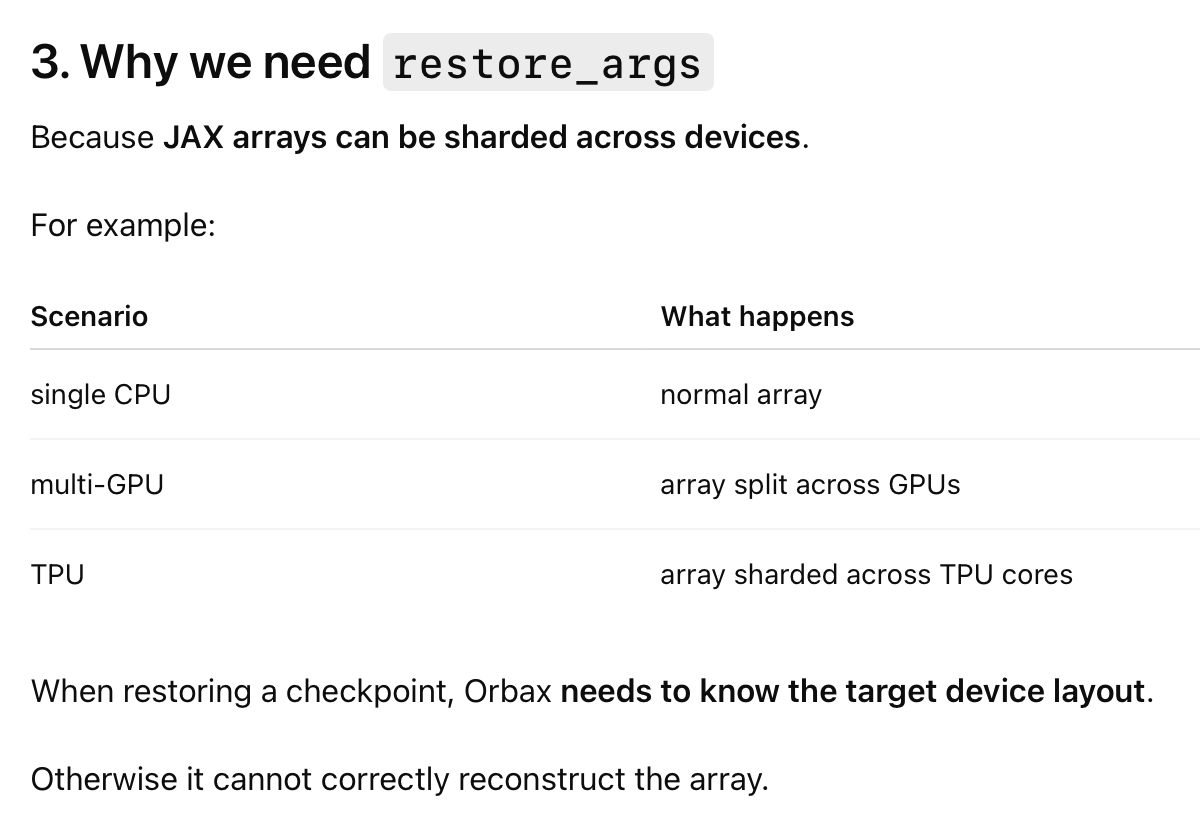

In [87]:
# restore_args tells Orbax how each array should be restored.
restore_args = jax.tree_util.tree_map(
    lambda _: checkpoint.ArrayRestoreArgs(sharding=cpu_sharding),
    nnx.state(model)
)

In [88]:
nnx.state(model)

State({
  'embedding': {
    'pos_emb': {
      'embedding': Param( # 24,576 (98.3 KB)
        value=Array([[-0.17664638, -0.14348212,  0.01510953, ...,  0.00471311,
                 0.07323164,  0.0555193 ],
               [ 0.07562244,  0.02320615, -0.0612787 , ...,  0.01456485,
                 0.00803979,  0.02886905],
               [ 0.00966623, -0.10108913, -0.09671812, ..., -0.05609718,
                 0.05831262,  0.00849283],
               ...,
               [-0.01381577,  0.09944122, -0.10008888, ..., -0.0627869 ,
                -0.14021668,  0.03156982],
               [ 0.04184169,  0.11759656,  0.06156824, ...,  0.00250981,
                 0.09520046, -0.02263859],
               [ 0.00363647,  0.04417636,  0.03465375, ..., -0.02581125,
                 0.06426496, -0.00050744]], dtype=float32)
      )
    },
    'token_emb': {
      'embedding': Param( # 9,649,344 (38.6 MB)
        value=Array([[ 0.06855264, -0.07013285, -0.05838477, ...,  0.09214087,
              

In [89]:
checkpoint_path = Path.cwd() / "llm_checkpoint.orbax"
checkpointer = orbax.checkpoint.PyTreeCheckpointer()

In [90]:
# Orbax reads the checkpoint file from disk and reconstructs the model parameters.
    # item=nnx.state(model) :	Provides the structure (PyTree layout) of the model parameters
    # restore_args=restore_args	: Tells how each array should be restored (device, sharding, etc.)
restored_state = checkpointer.restore(
    checkpoint_path,
    item=nnx.state(model),
    restore_args=restore_args)

nnx.update(model,restored_state)

In [92]:
def generate_text(model, start_tokens, max_new_tokens=50, temperature=1.0):
    # Convert the starting tokens into a mutable list
    tokens = list(start_tokens)

    # Generate tokens one by one
    for _ in range(max_new_tokens):

        # Take the last maxlen tokens as the context window
        context = tokens[-model.maxlen:]

        # RIGHT-pad with zeros if the context is shorter than maxlen
        actual_len = len(context)
        if actual_len < model.maxlen:
            context = context + [0] * (model.maxlen - actual_len)

        # Convert context into JAX array and add batch dimension
        context_array = jnp.array(context)[None, :]

        # Run the model to get logits
        logits = model(context_array)

        # Select logits corresponding to the last real token position
        next_token_logits = logits[0, actual_len - 1, :] / temperature

        # Choose the most probable next token
        next_token = int(jnp.argmax(next_token_logits))

        # Stop generation if end-of-text token appears
        if next_token == tokenizer.encode('<|endoftext|>', allowed_special={'<|endoftext|>'})[0]:
            break

        # Append generated token to the token list
        tokens.append(next_token)

    # Convert tokens back into text
    return tokenizer.decode(tokens)



In [93]:

def generate_capital(model, country_prompt, temperature=1.0, max_new_tokens=20):
    # Convert the input country prompt into token IDs
    start_tokens = tokenizer.encode(country_prompt)[:model.maxlen]

    # Generate the model output text
    generated = generate_text(
        model,
        start_tokens,
        max_new_tokens=max_new_tokens,
        temperature=temperature
    )

    return generated



In [58]:

generate_capital(
    model,
    country_prompt="What is the capital of USA",
    temperature=0,
    max_new_tokens=20
)

'What is the capital of USA!!!!!!!!!!!!!!!!!!!!'

In [94]:

generate_capital(
    model,
    country_prompt="What is the capital of russia",
    temperature=0,
    max_new_tokens=20
)

'What is the capital of russia!!!!!!!!!!!!!!!!!!!!'

In [69]:

generate_capital(
    model,
    country_prompt="What is the capital of russia ",
    temperature=0,
    max_new_tokens=20
)

'What is the capital of russia is Vienna'